## 1) Préparation de l'environnement

Cette cellule installe les bibliothèques nécessaires à l'analyse financière en Python (`yfinance`, `statsmodels`).

L'objectif est d'avoir un environnement reproductible pour :
- récupérer les données de marché,
- faire des tests économétriques,
- estimer des modèles de risque/rendement.

In [1]:
pip install -r requirements.txt

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 5.6 MB/s eta 0:00:19
    --------------------------------------- 2.1/101.7 MB 7.3 MB/s eta 0:00:14
   -- ------------------------------------- 5.8/101.7 MB 12.2 MB/s eta 0:00:08
   ---- ----------------------------------- 10.2/101.7 MB 14.5 MB/s eta 0:00:07
   ----- ---------------------------------- 13.6/101.7 MB 15.0 MB/s eta 0:00:06
   ------- -------------------------------- 17.8/101.7 MB 15.8 MB/s eta 0:00:06
   -------- ------------------------------- 21.5/101.7 MB 16.4 MB/s eta 0:00:05
   ---------- ----------------------------- 26.0/101.7 MB 16.8 MB/s eta 0:00:05
   ----------- ---------------------------- 30.4/101.7 MB 17.2 MB/s eta 0:00:05
   ------------- -------------------------- 34.3/101.7 MB 17.4 MB/s eta 0:00:04
   --------------- ------------------------ 38.8/101.7 MB 17.7 MB/s eta 0:00:04
   ----------------- ---------------------- 43.8/101.7


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\33768\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2) Imports et cadre d'analyse

Ici, on importe les modules pour manipuler les séries temporelles financières et produire les graphiques.

Notion clé : une série de prix boursiers est une **série temporelle**. On étudie son évolution dans le temps pour mesurer :
- la tendance,
- le risque (volatilité),
- et la relation avec le marché.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
import seaborn as sns

## 3) Collecte des données de marché

Cette cellule télécharge les prix de clôture des GAFAM et de deux indices de référence (`S&P 500`, `Nasdaq`) depuis Yahoo Finance.

Notion finance : le **prix de clôture** est souvent utilisé comme référence quotidienne, car il résume la valorisation de l'actif en fin de séance.

In [3]:

from src.data_utils import download_adj_close

# choisir une entreprise (l'entreprise à un nom légèrement différent sur les marchés financiers)
tickers = ["AAPL", "AMZN", "META", "GOOGL", "MSFT", "^GSPC", "^IXIC"]

# télécharger les données via la fonction utilitaire du projet
close = download_adj_close(tickers, start="2018-01-01", end="2026-12-31")

# afficher les premières lignes
print(close)
print(close.columns)

Ticker            AAPL        AMZN       GOOGL        META        MSFT  \
Date                                                                     
2018-01-02   40.304176   59.450500   53.220634  180.007401   78.870369   
2018-01-03   40.297157   60.209999   54.128624  183.232071   79.237411   
2018-01-04   40.484341   60.479500   54.338886  182.894730   79.934807   
2018-01-05   40.945259   61.457001   55.059433  185.395142   80.925858   
2018-01-08   40.793182   62.343498   55.253830  186.813980   81.008461   
...                ...         ...         ...         ...         ...   
2026-04-21  266.170013  249.910004  332.290009  668.840027  424.160004   
2026-04-22  273.170013  255.360001  339.320007  674.719971  432.920013   
2026-04-23  273.429993  255.080002  338.890015  659.150024  415.750000   
2026-04-24  271.059998  263.989990  344.399994  675.030029  424.619995   
2026-04-27  267.609985  261.119995  350.339996  678.619995  424.820007   

Ticker            ^GSPC         ^IXIC

## 4) Visualisation des prix bruts

On renomme les tickers pour une lecture plus claire puis on trace les prix de clôture.

Attention à l'interprétation : comparer des **prix bruts** est utile visuellement, mais cela peut être trompeur car chaque actif a une échelle de prix différente.

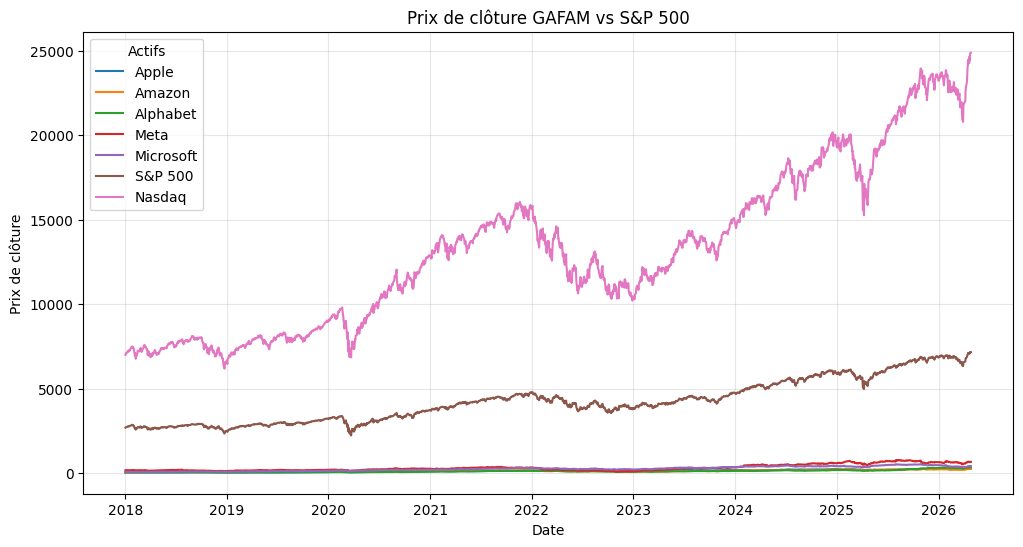

In [4]:
# noms de code sur les marchés en noms connus
close = close.rename(columns={
    "AAPL": "Apple",
    "AMZN": "Amazon",
    "META": "Meta",
    "GOOGL": "Alphabet",
    "MSFT": "Microsoft",
    "^GSPC": "S&P 500",
    "^IXIC": "Nasdaq"
})

# Plot
plt.figure(figsize=(12,6))

for col in close.columns:
    plt.plot(close.index, close[col], label=col)

plt.title("Prix de clôture GAFAM vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.legend(title="Actifs")
plt.grid(True, alpha=0.3)
plt.show()

## 5) Normalisation en base 100

Visualiser les données ainsi se révèle difficile, de fait le niveau du NASDAQ et du S&P 500 sont beaucoup plus élevé que le niveau des GAFAM; ce qui rend invisible les fortes variations du prix des GAFAM.

La prochaine cellule transforme chaque série de prix en **base 100** à la date initiale.

Notion finance : la base 100 permet de comparer les performances relatives de plusieurs actifs, indépendamment de leur niveau de prix initial.

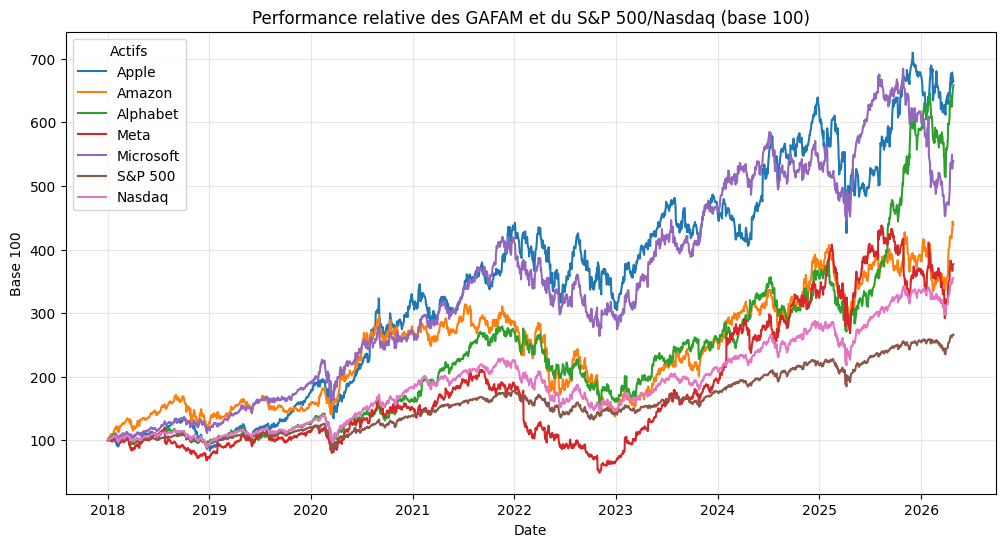

In [5]:
# Base 100
close_base100 = close / close.iloc[0] * 100

# Plot
plt.figure(figsize=(12,6))

for col in close_base100.columns:
    plt.plot(close_base100.index, close_base100[col], label=col)

plt.title("Performance relative des GAFAM et du S&P 500/Nasdaq (base 100)")
plt.xlabel("Date")
plt.ylabel("Base 100")
plt.legend(title="Actifs")
plt.grid(True, alpha=0.3)

plt.show()

## 6) Test de stationnarité (ADF) sur les prix

On applique le test Augmented Dickey-Fuller (ADF) sur chaque série de prix.

Notion économétrique :
- **H0** : la série a une racine unitaire (non stationnaire),
- **H1** : la série est stationnaire.

En finance, les prix sont souvent non stationnaires, ce qui motive l'utilisation des rendements pour la modélisation.

In [6]:


for col in close.columns:
    result = adfuller(close[col].dropna())
    print(f"{col}")
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print("-" * 30)

#On ne rejette pas H0
#La série des prix de l’action est non stationnaire.

Apple
ADF statistic: -0.514735091615198
p-value: 0.889108825312371
------------------------------
Amazon
ADF statistic: -0.9715366824386129
p-value: 0.7635035914746736
------------------------------
Alphabet
ADF statistic: 2.1895234614073473
p-value: 0.9988737737052865
------------------------------
Meta
ADF statistic: -0.2924550817743503
p-value: 0.9265661417797839
------------------------------
Microsoft
ADF statistic: -1.0468212067470142
p-value: 0.7358068144124817
------------------------------
S&P 500
ADF statistic: 0.46212675531458336
p-value: 0.983675356949905
------------------------------
Nasdaq
ADF statistic: 0.4246627181361831
p-value: 0.9823941752846305
------------------------------


## 7) Passage aux rendements logarithmiques

Cette cellule calcule les **rendements logarithmiques** (log-returns) :

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Pourquoi c'est important :
- les rendements sont en général plus proches de la stationnarité que les prix,
- ils sont additifs dans le temps,
- ils permettent de comparer plus proprement le risque entre actifs.

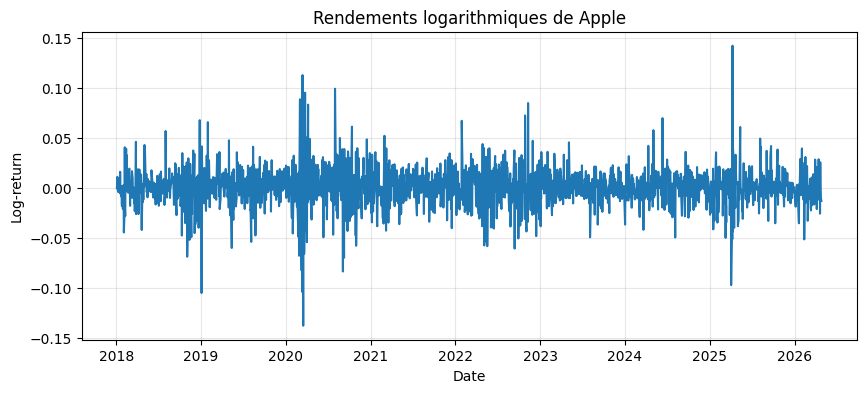

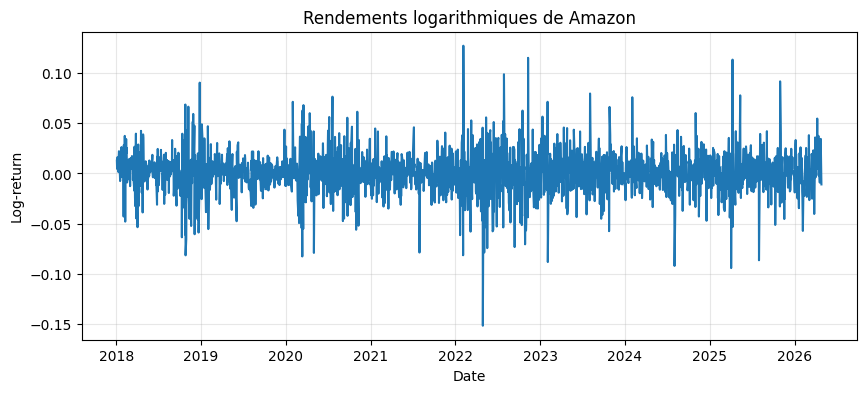

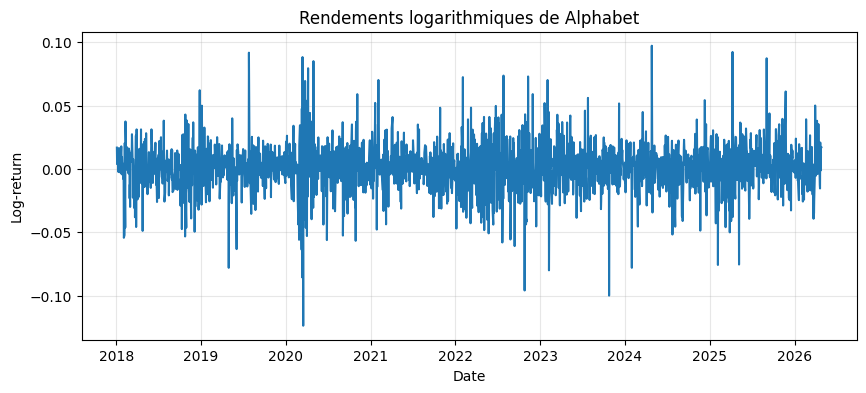

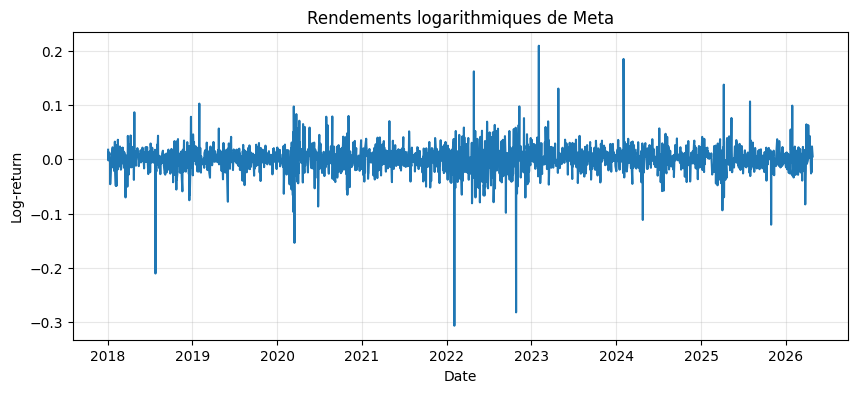

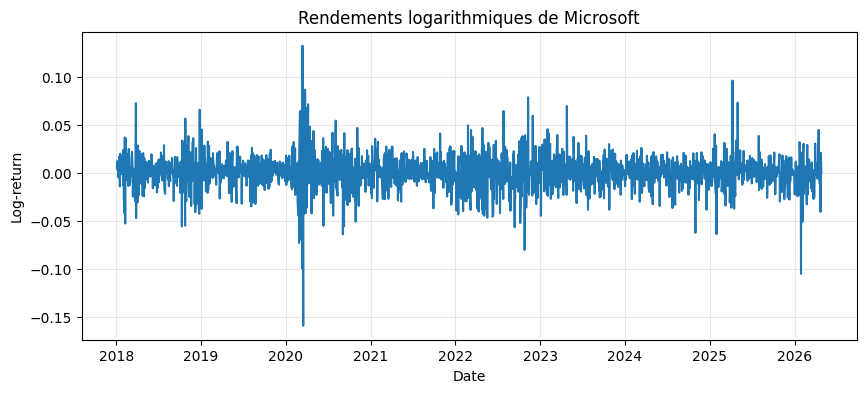

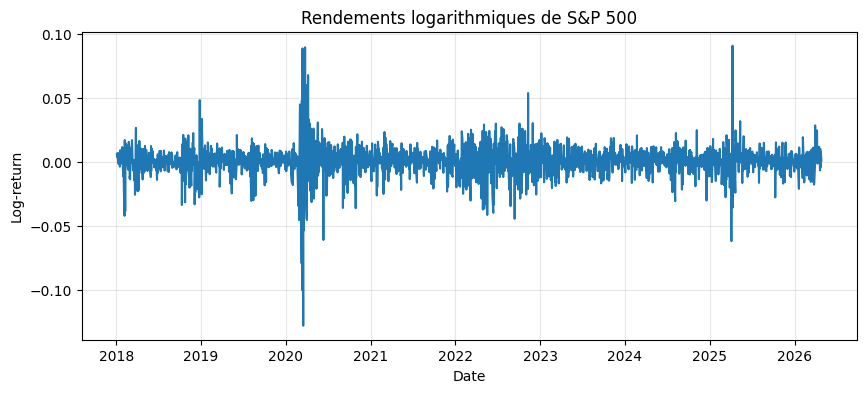

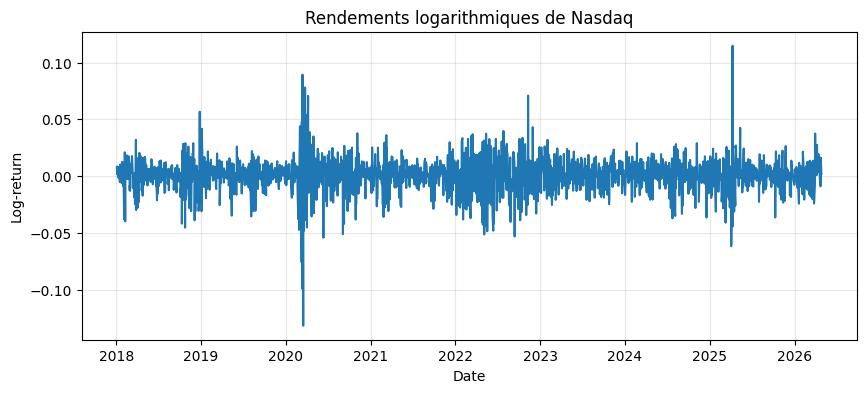

In [7]:

from src.data_utils import compute_log_returns

# Rendements logarithmiques
returns = compute_log_returns(close)

# Un graphique par actif
for col in returns.columns:
    plt.figure(figsize=(10,4))
    plt.plot(returns.index, returns[col])
    plt.title(f"Rendements logarithmiques de {col}")
    plt.xlabel("Date")
    plt.ylabel("Log-return")
    plt.grid(True, alpha=0.3)
    plt.show()

## 9) CAPM : alpha, beta et rendements excedentaires

On construit ici une estimation CAPM pour chaque action :
1. recuperation du taux sans risque (`^IRX`),
2. calcul des rendements excedentaires (actif - sans risque),
3. regression OLS contre deux marches de reference (`S&P 500` et `Nasdaq`).

Formules du modele CAPM (version empirique) :

$$
R_i - R_f = \alpha_i + \beta_i (R_m - R_f) + \varepsilon_i
$$

$$
\beta_i = \frac{\mathrm{Cov}(R_i - R_f,\; R_m - R_f)}{\mathrm{Var}(R_m - R_f)}
$$

$$
\alpha_i = \mathbb{E}[R_i - R_f] - \beta_i\,\mathbb{E}[R_m - R_f]
$$

Interpretation financiere :
- **beta** mesure la sensibilite de l'actif au marche (risque systematique),
- **alpha** mesure la performance anormale (sur/sous-performance apres ajustement du risque de marche),
- **R²** indique la part de variance expliquee par le facteur marche.

In [8]:
# 5. Taux sans risque (^IRX)
rf_raw = yf.download("^IRX", start="2018-01-01", auto_adjust=True)["Close"]

# Si yf renvoie un DataFrame à une colonne, on le transforme en Series
if isinstance(rf_raw, pd.DataFrame):
    rf_raw = rf_raw.squeeze()

# Réindexation sur les dates des rendements
rf_raw = rf_raw.reindex(returns.index).ffill()

# Conversion en taux journalier décimal
rf_daily = (rf_raw / 100) / 252

# 6. Rendements excédentaires
excess_returns = returns.sub(rf_daily, axis=0).dropna()

# Vérification utile
print("Colonnes excess_returns :", excess_returns.columns)
print("Nombre de lignes :", len(excess_returns))

# 7. Marchés
market_sp = excess_returns["S&P 500"]
market_nasdaq = excess_returns["Nasdaq"]

# 8. Régressions
rows = []

for col in excess_returns.columns:
    if col not in ["S&P 500", "Nasdaq"]:

        # ------- Régression contre S&P 500 -------
        tmp_sp = pd.concat([excess_returns[col], market_sp], axis=1).dropna()
        tmp_sp.columns = ["y", "market"]

        X_sp = sm.add_constant(tmp_sp["market"])
        model_sp = sm.OLS(tmp_sp["y"], X_sp).fit()

        # ------- Régression contre Nasdaq -------
        tmp_nq = pd.concat([excess_returns[col], market_nasdaq], axis=1).dropna()
        tmp_nq.columns = ["y", "market"]

        X_nq = sm.add_constant(tmp_nq["market"])
        model_nq = sm.OLS(tmp_nq["y"], X_nq).fit()

        rows.append({
            "asset": col,
            "alpha_sp": model_sp.params["const"],
            "beta_sp": model_sp.params["market"],
            "R2_sp": model_sp.rsquared,
            "alpha_nasdaq": model_nq.params["const"],
            "beta_nasdaq": model_nq.params["market"],
            "R2_nasdaq": model_nq.rsquared
        })

df_capm = pd.DataFrame(rows).set_index("asset")
print(df_capm.round(6))

[*********************100%***********************]  1 of 1 completed

Colonnes excess_returns : Index(['Apple', 'Amazon', 'Alphabet', 'Meta', 'Microsoft', 'S&P 500',
       'Nasdaq'],
      dtype='object', name='Ticker')
Nombre de lignes : 2089
           alpha_sp   beta_sp     R2_sp  alpha_nasdaq  beta_nasdaq  R2_nasdaq
asset                                                                        
Apple      0.000362  1.207109  0.591952      0.000280     1.038830   0.645688
Amazon     0.000174  1.179774  0.448478      0.000043     1.116214   0.591261
Alphabet   0.000377  1.155705  0.532934      0.000285     1.020241   0.611682
Meta       0.000047  1.328457  0.382944     -0.000082     1.220170   0.475796
Microsoft  0.000275  1.171386  0.638018      0.000190     1.018111   0.709845


## 10) Corrélation et causalité de Granger

L’estimation d’un modèle CAPM pour chaque action permet d’évaluer son rendement en fonction du marché et du niveau de risque. Toutefois, dans une optique de construction de portefeuille, il est essentiel d’aller au-delà de cette analyse individuelle et de s’intéresser aux relations entre les titres, en particulier à leur corrélation.

La corrélation mesure l’intensité des co-mouvements entre actifs, mais elle reste une mesure statique et symétrique, sans information sur la dynamique ou la direction des relations. Pour approfondir cette analyse, la causalité de Granger permet d’examiner si les rendements passés d’un actif apportent une information utile pour prédire ceux d’un autre. Elle introduit ainsi une dimension temporelle et directionnelle, complémentaire à la corrélation, et peut mettre en évidence des relations de dépendance potentiellement exploitables dans une stratégie d’investissement.

## 10.1) Matrice de correlation

Cette cellule visualise la correlation lineaire entre rendements des actifs.

- proche de `1` : mouvements souvent dans le meme sens ;
- proche de `-1` : mouvements souvent opposes ;
- proche de `0` : relation lineaire faible.

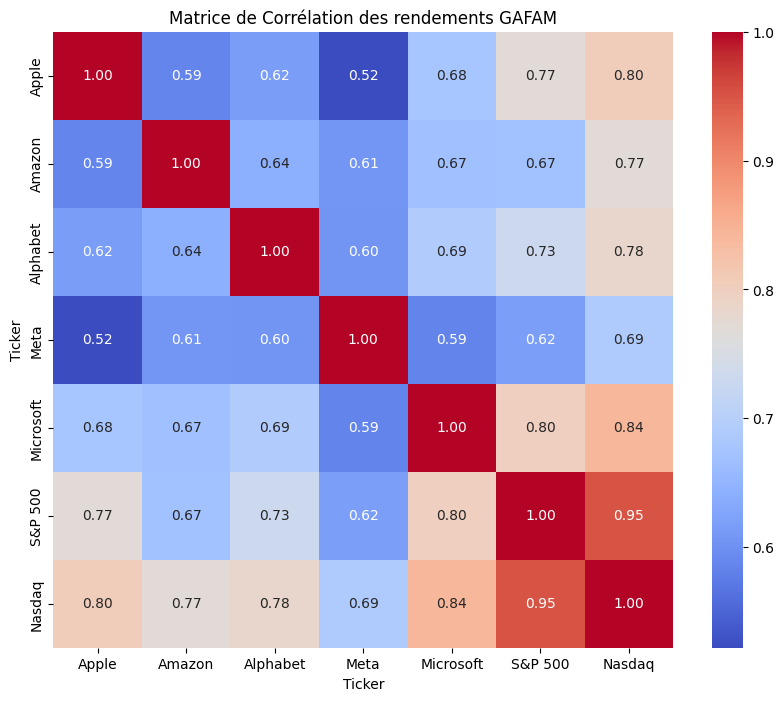

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des rendements GAFAM")
plt.show()

L’ensemble des corrélations entre les actions des GAFAM est supérieur à 0,5, ce qui traduit une forte dépendance entre ces titres. Autrement dit, ils ont tendance à évoluer dans le même sens, réagissant de manière similaire aux conditions de marché.

Dans ce contexte, les bénéfices de diversification sont fortement limités. Or, la diversification est précisément le principal levier permettant d’améliorer le couple rendement/risque d’un portefeuille. Ainsi, un portefeuille composé uniquement de GAFAM, malgré la qualité intrinsèque de ces entreprises, présente une capacité réduite à réduire le risque spécifique.

Par conséquent, il a peu de chances de surperformer le marché de manière ajustée du risque, car il reste fortement exposé à un même facteur de risque systémique, en l’occurrence celui du secteur technologique.

### 10.2) Test de causalite de Granger

La prochaine cellule teste si les rendements d'un actif aident a predire ceux d'un autre actif.

Hypotheses du test :
- `H0` : les retards du predicteur n'ameliorent pas la prediction de la cible (pas de causalite de Granger) ;
- `H1` : au moins un retard du predicteur ameliore la prediction de la cible (causalite de Granger).

Interpretation rapide :
- une p-value faible conduit a rejeter `H0` au seuil choisi ;
- cela ne prouve pas une causalite economique structurelle.

In [10]:
from src.metrics import test_granger
# Exemple entre Apple et les autres GAFAM
test_granger(returns, "Apple", "Microsoft")
test_granger(returns, "Apple", "Alphabet")
test_granger(returns, "Apple", "Amazon")
test_granger(returns, "Apple", "Meta")





--- Test de Granger : Microsoft cause-t-il Apple ? ---
Lag 1: p-value = 0.0091
Lag 2: p-value = 0.0267
Lag 3: p-value = 0.0071
Lag 4: p-value = 0.0101
Lag 5: p-value = 0.0101

--- Test de Granger : Alphabet cause-t-il Apple ? ---
Lag 1: p-value = 0.2163
Lag 2: p-value = 0.4807
Lag 3: p-value = 0.6737
Lag 4: p-value = 0.4328
Lag 5: p-value = 0.5457

--- Test de Granger : Amazon cause-t-il Apple ? ---
Lag 1: p-value = 0.9469
Lag 2: p-value = 0.9562
Lag 3: p-value = 0.8103
Lag 4: p-value = 0.2929
Lag 5: p-value = 0.2380

--- Test de Granger : Meta cause-t-il Apple ? ---
Lag 1: p-value = 0.2789
Lag 2: p-value = 0.1589
Lag 3: p-value = 0.1999
Lag 4: p-value = 0.0595
Lag 5: p-value = 0.0835


C:\Users\33768\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\33768\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\33768\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\33768\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verb

Les tests de causalité de Granger indiquent que les rendements passés de Microsoft apportent une information prédictive significative sur ceux d’Apple, comme en témoignent les p-values inférieures à 5% pour l’ensemble des retards considérés.

Cependant, cette relation ne doit pas être interprétée comme une causalité économique directe. La causalité de Granger capture une relation de prédictibilité et peut refléter la présence de facteurs communs ou des effets de décalage dans la réaction des actifs à l’information de marché. Dans le cas des GAFAM, fortement corrélées et exposées aux mêmes dynamiques sectorielles, ces résultats sont donc à interpréter avec prudence.